### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score , classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from catboost import CatBoostClassifier

from sklearn.linear_model import LinearRegression, ElasticNet
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor



### Reading the dataset

In [4]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv("C:\\Users\\User\\Downloads\\adult.data.csv",names = columns)
#Display the first 5 records.
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Info and Statistics of the dataset

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Preprocessig

In [6]:
#Check if there any missing values.
df.isna().sum().sum()

np.int64(0)

In [8]:
#Check in there any duplicates, then drop them if exists.
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

In [9]:
#Detect outliers
#numeric_cols = ["age", "fnlwgt", "education-num",'capital-gain','capital-loss','hours-per-week']

#Q1 = df[numeric_cols].quantile(0.25)
#Q3 = df[numeric_cols].quantile(0.75)
#IQR = Q3 - Q1

#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).sum()

#print("Number of outliers per column:")
#print(outliers)

In [10]:
#Handle outliers
#df[numeric_cols] = df[numeric_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

In [11]:
#Encode categorical features
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
#Train-test-split the data
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#Scale the train, test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

X_train_scaled_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_balanced.value_counts())

Before SMOTE: income
0    19778
1     6270
Name: count, dtype: int64

After SMOTE: income
1    19778
0    19778
Name: count, dtype: int64


### Voting Classifier

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')

voting_model = VotingClassifier(
    estimators=[
        ('rf', model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)


voting_model.fit(X_train_scaled_balanced, y_train_balanced)
y_pred_voting = voting_model.predict(X_test_scaled)

precision_voting = precision_score(y_test, y_pred_voting)
recall_voting = recall_score(y_test, y_pred_voting)
f1_score_voting = f1_score(y_test, y_pred_voting)

print("Voting Classifier Precision:", round(precision_voting, 2))
print("Voting Classifier Recall:", round(recall_voting, 2))
print("Voting Classifier F1_score:", round(f1_score_voting, 2))

print("Voting Classifier Accuracy:", round(accuracy_score(y_test, y_pred_voting)*100, 2), "%")
print(classification_report(y_test, y_pred_voting))

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:53:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Voting Classifier Precision: 0.69
Voting Classifier Recall: 0.76
Voting Classifier F1_score: 0.73
Voting Classifier Accuracy: 86.09 %
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      4942
           1       0.69      0.76      0.73      1571

    accuracy                           0.86      6513
   macro avg       0.81      0.83      0.82      6513
weighted avg       0.87      0.86      0.86      6513



### XGBClassifier

In [16]:
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled_balanced, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_test_scaled)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_score_xgb = f1_score(y_test, y_pred_xgb)

print("XGB Classifier Precision:", round(precision_xgb, 2))
print("XGB Classifier Recall:", round(recall_xgb, 2))
print("XGB Classifier F1_score:", round(f1_score_xgb, 2))

print("XGBoost Accuracy:", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print(classification_report(y_test, y_pred_xgb))

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:53:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Classifier Precision: 0.67
XGB Classifier Recall: 0.8
XGB Classifier F1_score: 0.73
XGBoost Accuracy: 85.77 %
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      4942
           1       0.67      0.80      0.73      1571

    accuracy                           0.86      6513
   macro avg       0.80      0.84      0.82      6513
weighted avg       0.87      0.86      0.86      6513



### Random Forest Classifier

In [17]:
#Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled_balanced, y_train_balanced)

#Evaluation
y_pred_RFC = model.predict(X_test_scaled)

precision_RFC = precision_score(y_test, y_pred_RFC)
recall_RFC = recall_score(y_test, y_pred_RFC)
f1_score_RFC = f1_score(y_test, y_pred_RFC)

print("RandomForest Classifier Precision:", round(precision_RFC, 2))
print("RandomForest Classifier Recall:", round(recall_RFC, 2))
print("RandomForest Classifier F1_score:", round(f1_score_RFC, 2))

print(f"Model Accuracy: {accuracy_score(y_test, y_pred_RFC):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_RFC))

RandomForest Classifier Precision: 0.69
RandomForest Classifier Recall: 0.71
RandomForest Classifier F1_score: 0.7
Model Accuracy: 85.21%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4942
           1       0.69      0.71      0.70      1571

    accuracy                           0.85      6513
   macro avg       0.80      0.81      0.80      6513
weighted avg       0.85      0.85      0.85      6513



### Support Vector Machine

In [18]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled_balanced, y_train_balanced)

y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_score_svm = f1_score(y_test, y_pred_svm)

print("Support Vector Machine Precision:", round(precision_svm, 2))
print("Support Vector Machine Recall:", round(recall_svm, 2))
print("Support Vector Machine F1_score:", round(f1_score_svm, 2))

print("SVM Accuracy:", round(accuracy_svm*100, 2), "%")
print(classification_report(y_test, y_pred_svm))

Support Vector Machine Precision: 0.56
Support Vector Machine Recall: 0.87
Support Vector Machine F1_score: 0.68
SVM Accuracy: 80.42 %
              precision    recall  f1-score   support

           0       0.95      0.78      0.86      4942
           1       0.56      0.87      0.68      1571

    accuracy                           0.80      6513
   macro avg       0.75      0.82      0.77      6513
weighted avg       0.85      0.80      0.82      6513



### GussainNB

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)

y_pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_score_nb = f1_score(y_test, y_pred_nb)

print("Naive Bays Precision:", round(precision_nb, 2))
print("Naive Bays Recall:", round(recall_nb, 2))
print("Naive Bays F1_score:", round(f1_score_nb, 2))

print("Naïve Bayes Accuracy:", round(accuracy_nb*100, 2), "%")
print(classification_report(y_test, y_pred_nb))

Naive Bays Precision: 0.65
Naive Bays Recall: 0.32
Naive Bays F1_score: 0.43
Naïve Bayes Accuracy: 79.56 %
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      4942
           1       0.65      0.32      0.43      1571

    accuracy                           0.80      6513
   macro avg       0.73      0.63      0.65      6513
weighted avg       0.78      0.80      0.77      6513



### KNeighborsClassifier

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled_balanced, y_train_balanced)

y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)

print("KNeighborsClassifier Precision:", round(precision_knn, 2))
print("KNeighborsClassifier Recall:", round(recall_knn, 2))
print("KNeighborsClassifier F1_score:", round(f1_score_knn, 2))

print("KNN Accuracy:", round(accuracy_knn*100, 2), "%")
print(classification_report(y_test, y_pred_knn))


KNeighborsClassifier Precision: 0.54
KNeighborsClassifier Recall: 0.79
KNeighborsClassifier F1_score: 0.64
KNN Accuracy: 78.7 %
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4942
           1       0.54      0.79      0.64      1571

    accuracy                           0.79      6513
   macro avg       0.73      0.79      0.75      6513
weighted avg       0.83      0.79      0.80      6513



### Logistic Regression

In [21]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled_balanced, y_train_balanced)

y_pred_log = log_model.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)

precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_score_log = f1_score(y_test, y_pred_log)

print("Logistic Regerssion Precision:", round(precision_log, 2))
print("Logistic Regerssion Recall:", round(recall_log, 2))
print("Logistic Regerssion F1_score:", round(f1_score_log, 2))

print("Logistic Regression Accuracy:", round(accuracy_log*100, 2), "%")
print(classification_report(y_test, y_pred_log))

Logistic Regerssion Precision: 0.51
Logistic Regerssion Recall: 0.78
Logistic Regerssion F1_score: 0.62
Logistic Regression Accuracy: 76.78 %
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      4942
           1       0.51      0.78      0.62      1571

    accuracy                           0.77      6513
   macro avg       0.71      0.77      0.73      6513
weighted avg       0.82      0.77      0.78      6513



In [22]:
#Check the outliers.
numeric_cols = ["age", "fnlwgt", "education-num",'capital-gain','capital-loss','hours-per-week']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → {len(outliers)} outliers")

age → 143 outliers
fnlwgt → 992 outliers
education-num → 1198 outliers
capital-gain → 2712 outliers
capital-loss → 1519 outliers
hours-per-week → 9008 outliers


### Correlation

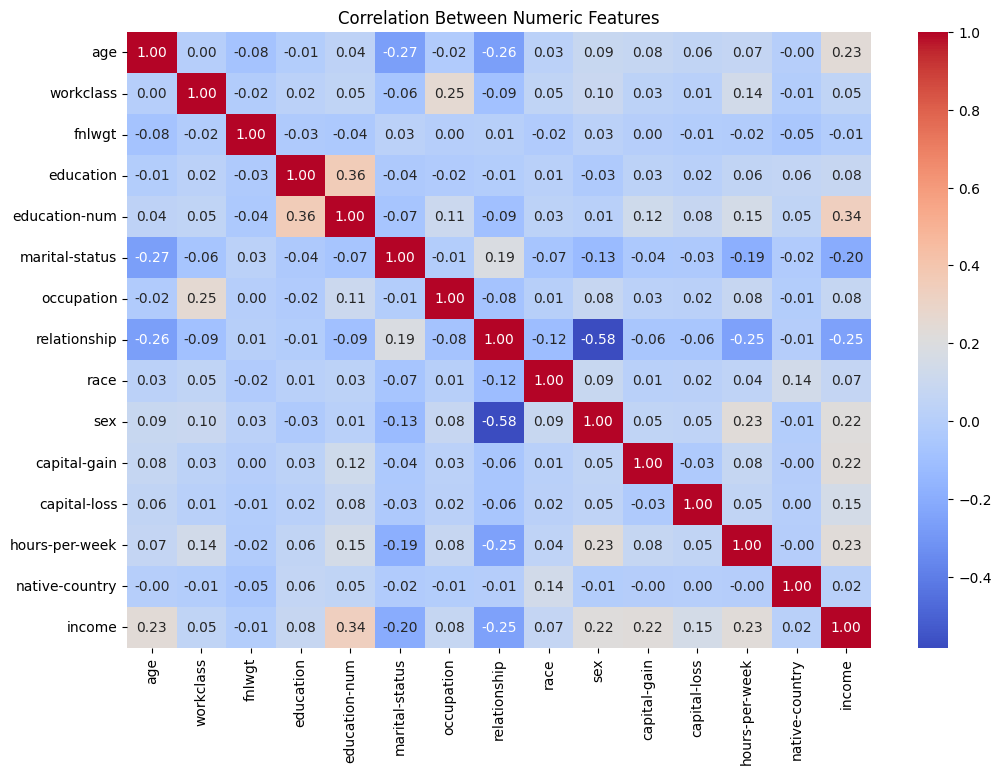

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

### Histogram

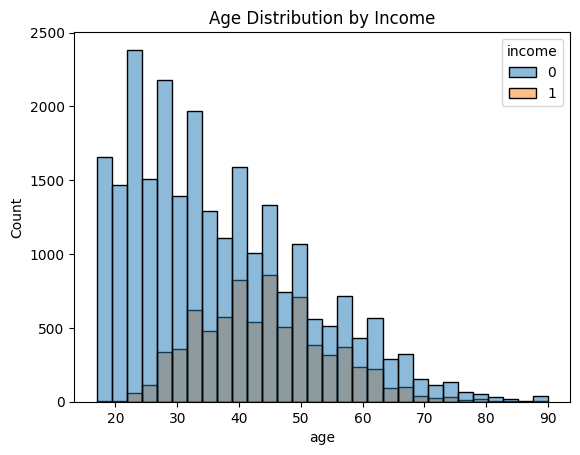

In [24]:
sns.histplot(data=df, x="age", hue="income", bins=30)
plt.title("Age Distribution by Income")
plt.show()

### Scatter plot

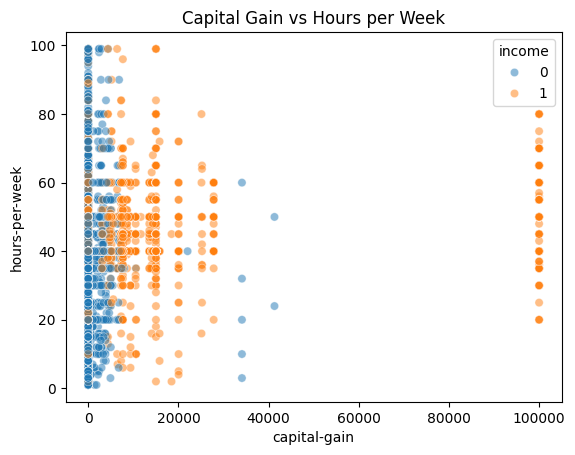

In [25]:
sns.scatterplot(x="capital-gain", y="hours-per-week", hue="income", data=df, alpha=0.5)
plt.title("Capital Gain vs Hours per Week")
plt.show()


### Countplot

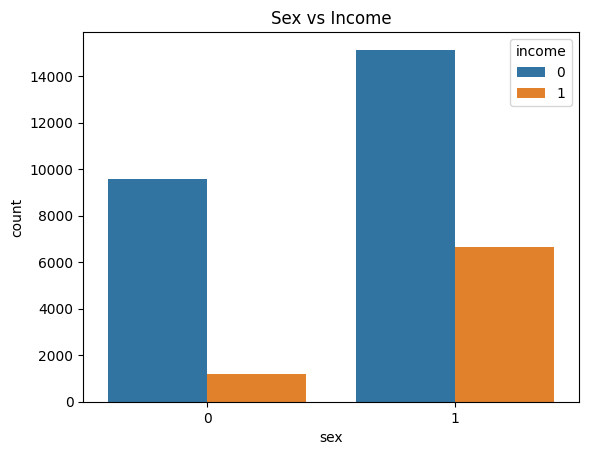

In [26]:
sns.countplot(x="sex", hue="income", data=df)
plt.title("Sex vs Income")
plt.show()

### Countplot

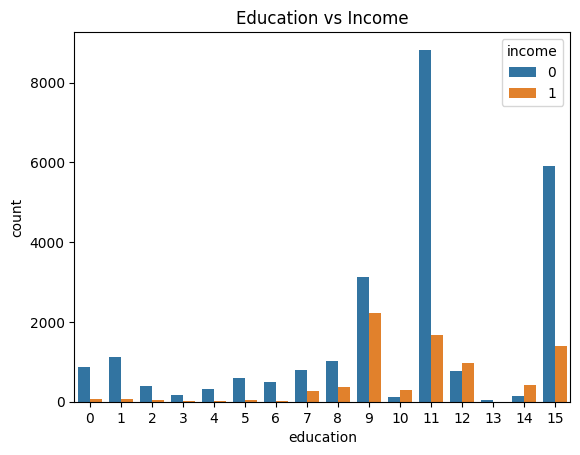

In [27]:
sns.countplot(x="education", hue="income", data=df)
plt.title("Education vs Income")
plt.show()